# name: seba saud

In [2]:

!apt-get install -y poppler-utils
!pip install -q pdf2image transformers accelerate flash-attn pillow

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  poppler-utils
0 upgraded, 1 newly installed, 0 to remove and 42 not upgraded.
Need to get 186 kB of archives.
After this operation, 697 kB of additional disk space will be used.
Ign:1 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 poppler-utils amd64 22.02.0-2ubuntu0.12
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 poppler-utils amd64 22.02.0-2ubuntu0.12 [186 kB]
Fetched 186 kB in 1min 18s (2,378 B/s)
Selecting previously unselected package poppler-utils.
(Reading database ... 122354 files and directories currently installed.)
Preparing to unpack .../poppler-utils_22.02.0-2ubuntu0.12_amd64.deb ...
Unpacking poppler-utils (22.02.0-2ubuntu0.12) ...
Setting up poppler-utils (22.02.0-2ubuntu0.12) ...
Processing triggers for man-db (2.10.2-1) ...
  Preparing metadata (setup.py) ... done
  error: subprocess-exited-with-e

In [5]:
!pip install -q pdf2image pillow
from pdf2image import convert_from_path
import os

pdf_path = 'my_cv (1).pdf'
images = convert_from_path(pdf_path)


images[0].save('resume_page.png', 'PNG')

print("تم تحويل الصفحة الأولى إلى صورة بنجاح!")

تم تحويل الصفحة الأولى إلى صورة بنجاح!


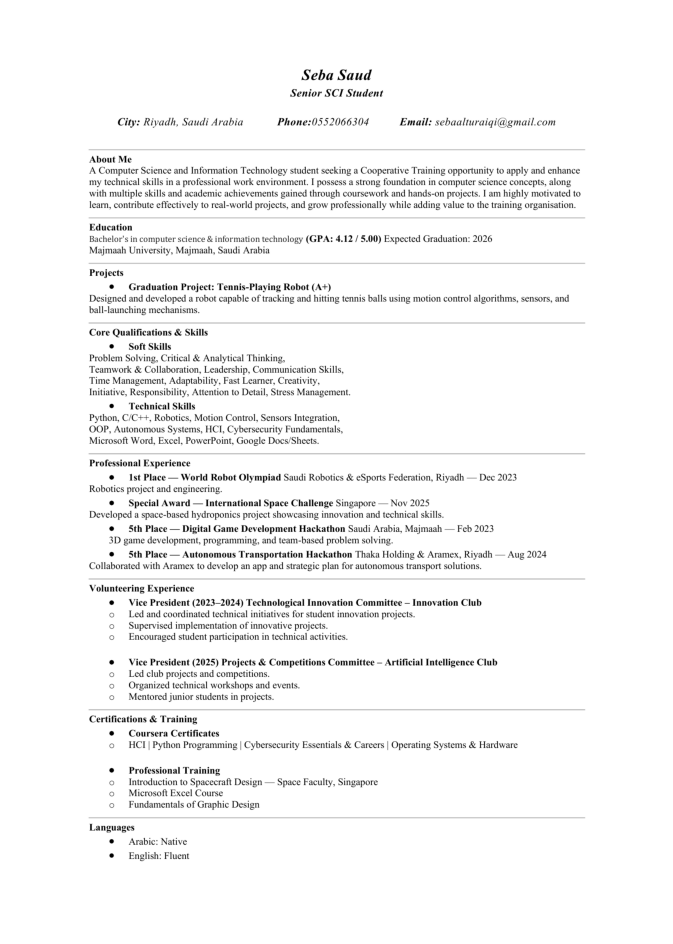

In [6]:
from PIL import Image
import matplotlib.pyplot as plt


img = Image.open('resume_page.png')


plt.figure(figsize=(12, 12))
plt.imshow(img)
plt.axis('off')
plt.show()

In [7]:
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor
from PIL import Image
import torch


model_id = "Qwen/Qwen2-VL-2B-Instruct"
model = Qwen2VLForConditionalGeneration.from_pretrained(
    model_id, torch_dtype="auto", device_map="auto"
)
processor = AutoProcessor.from_pretrained(model_id)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

...

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [11]:
import os
from pdf2image import convert_from_path

# Ensure poppler-utils is installed for pdf2image
!apt-get install -y poppler-utils

pdf_path = 'sample_data/my_cv.pdf'
image_out = 'resume_page.png'

if os.path.exists(pdf_path):
    images = convert_from_path(pdf_path)
    images[0].save(image_out, 'PNG')
    print("✅ تم العثور على الملف وتحويله بنجاح!")
else:
    print(f"❌ لم يتم العثور على الملف في المسار: {pdf_path}")

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  poppler-utils
0 upgraded, 1 newly installed, 0 to remove and 2 not upgraded.
Need to get 186 kB of archives.
After this operation, 697 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 poppler-utils amd64 22.02.0-2ubuntu0.12 [186 kB]
Fetched 186 kB in 1min 19s (2,363 B/s)
Selecting previously unselected package poppler-utils.
(Reading database ... 118194 files and directories currently installed.)
Preparing to unpack .../poppler-utils_22.02.0-2ubuntu0.12_amd64.deb ...
Unpacking poppler-utils (22.02.0-2ubuntu0.12) ...
Setting up poppler-utils (22.02.0-2ubuntu0.12) ...
Processing triggers for man-db (2.10.2-1) ...
✅ تم العثور على الملف وتحويله بنجاح!


In [6]:

!apt-get install -y poppler-utils
!pip install -q pdf2image transformers accelerate

import torch
from pdf2image import convert_from_path
from PIL import Image
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor
import os


pdf_path = 'sample_data/my_cv.pdf' # Corrected path
image_out = 'resume_page.png'

if os.path.exists(pdf_path):
    images = convert_from_path(pdf_path)
    images[0].save(image_out, 'PNG')
    print("✅ تم تحويل السيرة الذاتية بنجاح.")
else:
    print(f"❌ لم يتم العثور على الملف في المسار: {pdf_path}. لن يتم تشغيل المهام.")

# 3.Task 1 & Task 2
if os.path.exists(image_out):

    model_id = "Qwen/Qwen2-VL-2B-Instruct"
    model = Qwen2VLForConditionalGeneration.from_pretrained(
        model_id,
        torch_dtype=torch.float16,
        device_map="auto"
    )
    processor = AutoProcessor.from_pretrained(model_id)

    img = Image.open(image_out)


    prompt = "<|user|>\n<|vision_start|><|image_pad|><|vision_end|>1. Extract Name, Education, and Skills in JSON format. 2. استخرج النص العربي مع الحفاظ على التشكيل والتنسيق.<|assistant|>\n"

    inputs = processor(text=[prompt], images=[img], return_tensors="pt").to("cuda")

    with torch.no_grad():
        generated_ids = model.generate(**inputs, max_new_tokens=1000)
        result = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

    print("\n" + "="*30)
    print("🎯 النتائج النهائية للتمرين:")
    print("="*30)
    print(result)

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
poppler-utils is already the newest version (22.02.0-2ubuntu0.12).
0 upgraded, 0 newly installed, 0 to remove and 42 not upgraded.
✅ تم تحويل السيرة الذاتية بنجاح.


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]


🎯 النتائج النهائية للتمرين:
<|user|>
1. Extract Name, Education, and Skills in JSON format. 2. استخرج النص العربي مع الحفاظ على التشكيل والتنسيق.<|assistant|>
```json
{
  "name": "Seba Saud",
  "education": {
    "school": "Majmaah University",
    "major": "Bachelor's in Computer Science & Information Technology",
    "graduation_date": "2026",
    "expected_graduation_date": "2026",
    "gpa": 4.12,
    "gpa_rating": 5.00
  },
  "skills": [
    "Problem Solving",
    "Critical & Analytical Thinking",
    "Teamwork & Collaboration",
    "Leadership",
    "Communication Skills",
    "Time Management",
    "Adaptability",
    "Fast Learner",
    "Creativity",
    "Initiative",
    "Responsibility",
    "Attention to Detail",
    "Stress Management"
  ]
}
```

النص العربي مع الحفاظ على التشكيل والتنسيق:

```json
{
  "name": "Seba Saud",
  "education": {
    "school": "Majmaah University",
    "major": "Bachelor's in Computer Science & Information Technology",
    "graduation_date": "202